In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from tqdm import tqdm

## Prepare data

In [2]:
def get_x_y(periods):
    X, y = [], []
    for tp in tqdm(periods):
        irradiance_measurements = [float(item["irradiance"]) for item in tp["history"]]
        target_irradiance = float(tp["target_irradiance"])
        X.append(irradiance_measurements)
        y.append(target_irradiance)

    return np.array(X), np.array(y)

In [3]:
folsom_periods_path = Path("./periods.pickle")

with open(folsom_periods_path, "rb") as f:
    periods = pickle.load(f)

test_periods = list(filter(lambda p: p["history"][-1]["image_name"].startswith("2014"), periods))
train_val_periods = list(filter(lambda p: not p["history"][-1]["image_name"].startswith("2014"), periods))

# number of days for validatation dataset to get 80-20 ratio of train-val datasets
val_size = 146
np.random.seed(42)
val_dates = [
    str(y) + str(m).zfill(2) + str(d).zfill(2)
    for y, m, d in zip(
        np.random.randint(2015, 2017, size=val_size),
        np.random.randint(1, 13, size=val_size),
        np.random.randint(1, 29, size=val_size),
        strict=False,
    )
]
val_periods = list(filter(lambda p: p["history"][-1]["image_name"][:8] in val_dates, train_val_periods))
train_periods = list(filter(lambda p: p["history"][-1]["image_name"][:8] not in val_dates, train_val_periods))

print(f"Train size: {len(train_periods)}")
print(f"Validation size: {len(val_periods)}")
print(f"Test size: {len(test_periods)}")

Train size: 406168
Validation size: 89203
Test size: 224335


In [4]:
X_train, y_train = get_x_y(train_periods)
X_val, y_val = get_x_y(val_periods)
X_test, y_test = get_x_y(test_periods)

100%|██████████| 224335/224335 [00:00<00:00, 712049.98it/s]


## Linear Regression

In [5]:
linear_regression_model = LinearRegression()

linear_regression_model.fit(X_train, y_train)
(
    linear_regression_model.score(X_train, y_train),
    linear_regression_model.score(X_val, y_val),
    linear_regression_model.score(X_test, y_test),
)

(0.9068739573501323, 0.9071291381968667, 0.9087200043551132)

### Evaluate

In [6]:
linear_regression_predictions = []
for _X in tqdm(X_test):
    _X = np.array(_X).reshape(1, -1)
    pred = linear_regression_model.predict(_X)[0]
    linear_regression_predictions.append(float(pred))

100%|██████████| 224335/224335 [00:17<00:00, 12986.01it/s]


RMSE: 88.11863207030493
MAE: 56.7587242347094
MAPE: 0.4668553698229298


Text(0.5, 0, 'Time')

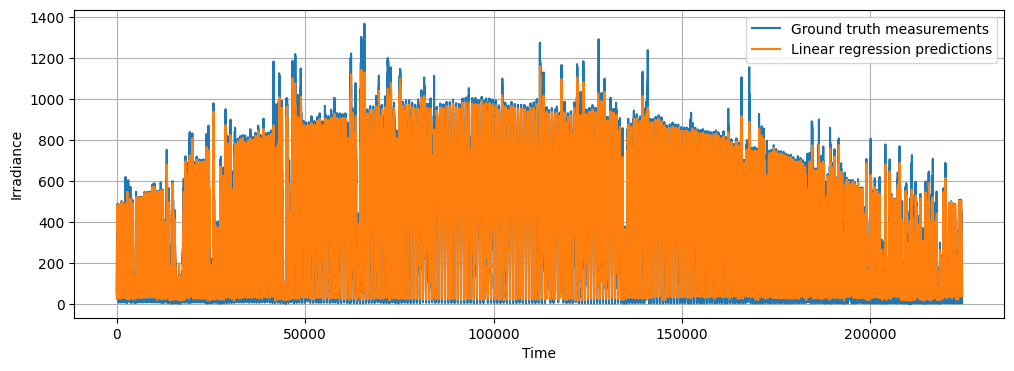

In [7]:
rmse = root_mean_squared_error(y_true=y_test, y_pred=np.array(linear_regression_predictions))
mae = mean_absolute_error(y_true=y_test, y_pred=np.array(linear_regression_predictions))
mape = mean_absolute_percentage_error(y_true=y_test, y_pred=np.array(linear_regression_predictions))

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}")

fig = plt.figure(figsize=(12, 4))

plt.plot(y_test)
plt.plot(linear_regression_predictions)
plt.legend(["Ground truth measurements", "Linear regression predictions"])
plt.grid(True)
plt.ylabel("Irradiance")
plt.xlabel("Time")

## Lasso Regressor

In [8]:
lasso_model = Lasso(random_state=42)

lasso_model.fit(X_train, y_train)
lasso_model.score(X_train, y_train), lasso_model.score(X_val, y_val), lasso_model.score(X_test, y_test)

(0.9068739477067197, 0.9071300606428379, 0.9087197824980371)

### Evaluate

In [9]:
lasso_predictions = []
for _X in tqdm(X_test):
    _X = np.array(_X).reshape(1, -1)
    pred = lasso_model.predict(_X)[0]
    lasso_predictions.append(float(pred))

  0%|          | 0/224335 [00:00<?, ?it/s]

100%|██████████| 224335/224335 [00:18<00:00, 12103.03it/s]


RMSE: 88.11873915691272
MAE: 56.76382725360226
MAPE: 0.4669157425929568


Text(0.5, 0, 'Time')

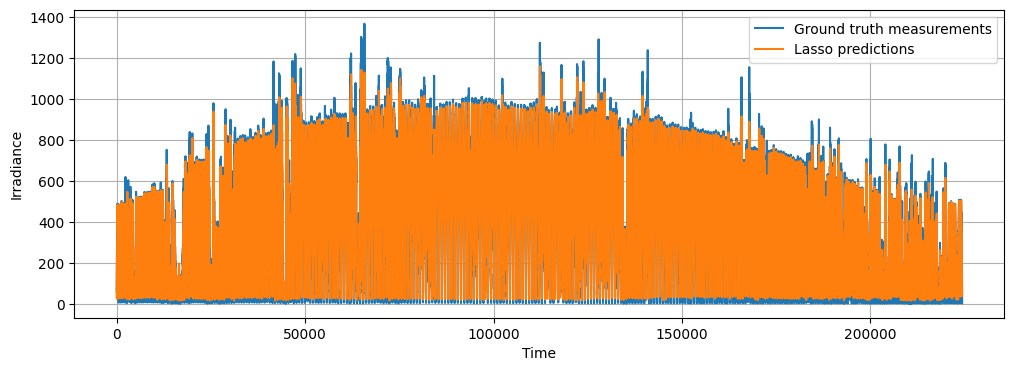

In [10]:
rmse = root_mean_squared_error(y_true=y_test, y_pred=np.array(lasso_predictions))
mae = mean_absolute_error(y_true=y_test, y_pred=np.array(lasso_predictions))
mape = mean_absolute_percentage_error(y_true=y_test, y_pred=np.array(lasso_predictions))

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}")

fig = plt.figure(figsize=(12, 4))

plt.plot(y_test)
plt.plot(lasso_predictions)
plt.legend(["Ground truth measurements", "Lasso predictions"])
plt.grid(True)
plt.ylabel("Irradiance")
plt.xlabel("Time")

## MLPRegressor

In [11]:
mlp_model = MLPRegressor(random_state=42)

mlp_model.fit(X_train, y_train)
mlp_model.score(X_train, y_train), mlp_model.score(X_val, y_val), mlp_model.score(X_test, y_test)

(0.9240710819134396, 0.9228736886302146, 0.9241906856480842)

### Evaluate

In [12]:
mlp_predictions = []
for _X in tqdm(X_test):
    _X = np.array(_X).reshape(1, -1)
    pred = mlp_model.predict(_X)[0]
    mlp_predictions.append(float(pred))

100%|██████████| 224335/224335 [00:28<00:00, 7779.57it/s]


RMSE: 80.30474838524005
MAE: 38.339517045711574
MAPE: 0.2356371563398517


Text(0.5, 0, 'Time')

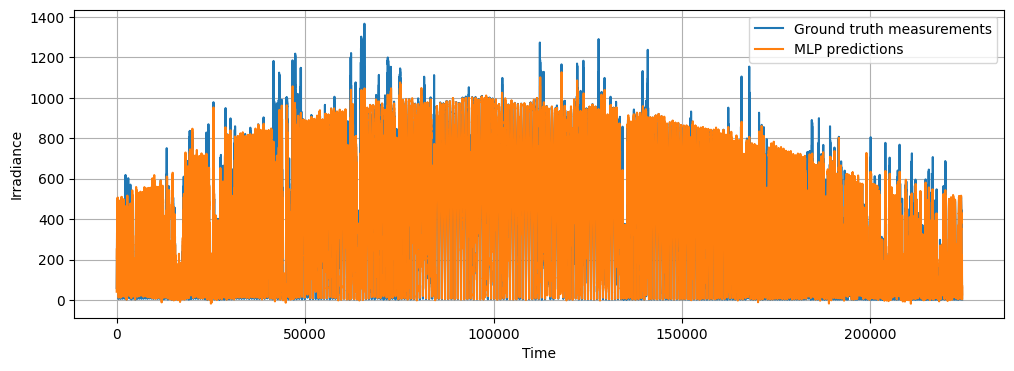

In [13]:
rmse = root_mean_squared_error(y_true=y_test, y_pred=np.array(mlp_predictions))
mae = mean_absolute_error(y_true=y_test, y_pred=np.array(mlp_predictions))
mape = mean_absolute_percentage_error(y_true=y_test, y_pred=np.array(mlp_predictions))

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}")

fig = plt.figure(figsize=(12, 4))

plt.plot(y_test)
plt.plot(mlp_predictions)
plt.legend(["Ground truth measurements", "MLP predictions"])
plt.grid(True)
plt.ylabel("Irradiance")
plt.xlabel("Time")